## To Do List
  1. Constructing the exact BW peaks
  2. Constructing the training data - correlators with noise
  3. Preparing the two NN representations
  4. Writing the Training loops
  5. Implementing the two losses with $\rho(\omega)$ the reconstructed spectral function and $\tilde{\rho}(\omega)$ - the ground truth
      - MSE with $\int^{\infty}_0 \left(\tilde{\rho}(\omega) - \rho(\omega) \right)$
      - DKL with $\int^{\infty}_0 \rho(\omega) \log \left( \frac{\rho(\omega)}{\tilde{\rho}(\omega)} \right)$
  7. Re-run the code with different instances of noice for $D(p_i)$ and perform a Jacknife analysis estimating the propagation of errors on $\rho (\omega)$

The BW peaks to be tested are the single and double as used in [this paper](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.106.L051502) , Section IV. Important details on the Training setups and Mock lattice data preparation are given in this [Supplemental paper](https://journals.aps.org/prd/supplemental/10.1103/PhysRevD.106.L051502/supplementary_material.pdf)

$\rho^{(BW)}(\omega) = \frac{4 A \Gamma \omega}{\left(M^2 + \Gamma^2 - \omega^2 \right)^2 + 4 \Gamma^2 \omega^2}$, with 
- $A=1.0$, $\Gamma=0.5$, $M=2.0$
- $A_1 = 0.8$, $A_2 = 1.0$,  $\Gamma_1=\Gamma_2=0.5$, $M_1=2.0$, $M_2=5.0$

In [5]:
import ray
from ray import train, tune
# from ray.tune.schedulers import AsyncHyperBandScheduler
# from ray.air.integrations.keras import ReportCheckpointCallback

In [6]:
import numpy as np
from matplotlib import pyplot as plt



In [7]:
## Constructing the exact BW peaks
##Single peak
A = np.array([1.0])
Ga = np.array([0.5])
M = np.array([2.0])
##Double peak
A = np.array([0.8,1.0])
Ga = np.array([0.5,0.5])
M = np.array([2.0,5.0])
#List of frequencies 
omega = np.linspace(0,19.96,500)
del_omega = omega[1]-omega[0]

In [4]:
def rhoOmega_offset(rho_true,rho_pred,range=3):
    return np.sum(np.abs(rho_true[:range]-np.squeeze(rho_pred.numpy())[:range]))

In [5]:
train_epochs=1000


base_ep_noise=0#3e-2
num_samples = 30
ep_noise=3e-2
seed=0

def train_NN_multifit(config):
    import physicsHelper
    import models
    import lossCalculator
    import correlator
    import tensorflow as tf
    
    spec2BW = physicsHelper.BWfun(A,Ga,M,omega)
    rho_true = spec2BW

    x = np.linspace(0,19.2+0,25)
    del_xi = x[1]-x[0]

    kl_ker_Pos=correlator.KL_kernel_Position_Vacuum(x,omega)
    klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)

    ##Again Dpi can represent both 1BW or 2BW depending on whether you pass spec1W or spec2W - Be careful!
    Dxi = correlator.Di(kl_ker_Pos,spec2BW,del_omega)

    noisy_dxi_tensor = []
    base_noisy_Dxi,custom_std=correlator.generateNoisyCorrelator(Dxi,x,base_ep_noise,seed=seed)
    if num_samples == 1:
        noisy_dxi_tensor.append(base_noisy_Dxi)
    else:
        for ii in range(num_samples):
            noisy_Dxi_sample,custom_std=correlator.generateNoisyCorrelator(base_noisy_Dxi,x,ep_noise)
            noisy_dxi_tensor.append(noisy_Dxi_sample)

    target_output = tf.constant(base_noisy_Dxi, dtype=tf.float32)
    target_output=noisy_dxi_tensor
    gauss_width = np.ones(len(x)) #for mean square error
    gauss_width=custom_std
    kern=klW_ker_Pos
    constant_input = tf.constant([[1.0]], dtype=tf.float32) #NN
    
    model = models.SpectralNN(num_output_nodes=500, width=config["width"], depth=config["depth"])
    lossCalc=lossCalculator.LossCalculatorHyperTuning(model=model,
                                            y_true=target_output,
                                            kernel=kern,
                                            delomega=del_omega,
                                            x=constant_input,
                                            std=gauss_width,
                                            lambda_s_func_warmup=lambda x:config["lambda_s_warmup"],
                                            lambda_s_func=lambda x:config["lambda_s"],
                                            lambda_l2_func_warmup=lambda x:config["lambda_l2_warmup"],
                                            lambda_l2_func=lambda x:config["lambda_l2"]
                                            )
    # Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
    trainer=models.networkTrainer(model,optimizer,lossCalc)
    total_loss_history_warmup,loss_history_warmup=trainer.train(config["warmup_epochs"],warmup=True,verbose=True)

    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5) #notice the lower learning rate
    trainer.optimizer=optimizer
    total_loss_history,loss_history=trainer.train(config["train_epochs"],warmup=False,verbose=True)
    rho_pred=model(constant_input)

    return rhoOmega_offset(rho_true,rho_pred,range=3)

In [6]:
# config = {
#     "lambda_s_warmup": 1.0e-2,
#     "lambda_l2_warmup": 1.0e-4,
#     "lambda_s": 1.0e-5,
#     "lambda_l2": 1.0e-8,
#     "warmup_epochs": 20
# }

# print(train_NN_multifit(config))

In [7]:
search_space = { 
    "lambda_s_warmup": 1.0e-2,#tune.loguniform(1.0e-2, 1.0e-1),
    "lambda_l2_warmup": 1.0e-4,#tune.loguniform(1.0e-4, 1.0e-3),
    "lambda_s": tune.loguniform(1.0e-7, 1.0e-3),
    "lambda_l2": tune.loguniform(1.0e-10, 1.0e-6),
    "warmup_epochs": 1000,
    "width": 64,
    "depth": 3,
    "train_epochs": 10000
}

In [8]:
ray.init(num_cpus=8)
trainable_with_resources = tune.with_resources(train_NN_multifit, {"cpu": 1})
tuner = tune.Tuner(trainable_with_resources, param_space=search_space,tune_config=tune.TuneConfig(num_samples=24)) 

2024-12-05 14:41:33,586	INFO worker.py:1821 -- Started a local Ray instance.


In [9]:
results = tuner.fit()

(train_NN_multifit pid=983744) 2024-12-05 14:41:42.459264: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
(train_NN_multifit pid=983744) 2024-12-05 14:41:42.467054: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
(train_NN_multifit pid=983744) 2024-12-05 14:41:42.489684: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(train_NN_multifit pid=983744) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(train_NN_multifit pid=983744) E0000 00:00:1733406102.525724  984234 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(train_NN_multifit pid=983744) E0000 00:00:1733406102.536181  984234 cuda_bla

(train_NN_multifit pid=983744) Training for 1000 epochs
(train_NN_multifit pid=983744) Epoch 0, Loss: 748.0252685546875
(train_NN_multifit pid=983749) Training for 1000 epochs [repeated 7x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(train_NN_multifit pid=983744) Epoch 100, Loss: 0.17123004794120789 [repeated 8x across cluster]
(train_NN_multifit pid=983744) Epoch 200, Loss: 0.058253753930330276 [repeated 8x across cluster]
(train_NN_multifit pid=983750) Epoch 300, Loss: 0.022815292701125145 [repeated 8x across cluster]
(train_NN_multifit pid=983749) Epoch 400, Loss: 0.012418070808053017 [repeated 8x across cluster]
(train_NN_multifit pid=983750) Epoch 500, Loss: 0.004862592555582523 [repeated 8x across cluster]
(train_NN_multifit pid=983750) Epoch 600, Loss: 0.00302530056796968 [repeated 8x across clust

(train_NN_multifit pid=993151) 2024-12-05 14:51:27.076087: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used. [repeated 16x across cluster]
(train_NN_multifit pid=983747) 2024-12-05 14:41:42.715462: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 7x across cluster]
(train_NN_multifit pid=983747) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR [repeated 7x across cluster]
(train_NN_multifit pid=983747) E0000 00:00:1733406102.758819  984276 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered [repeated 7x across cluster]
(train_NN_multifit pid=983747) E0000 00:00:1733406102.770569  984276 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to re

(train_NN_multifit pid=983744) Training took 527.1418981552124 seconds [repeated 4x across cluster]
(train_NN_multifit pid=993151) Training for 1000 epochs
(train_NN_multifit pid=993151) Epoch 0, Loss: 747.7412719726562


(train_NN_multifit pid=993382) 2024-12-05 14:51:30.940337: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used. [repeated 6x across cluster]
(train_NN_multifit pid=993382) 2024-12-05 14:51:30.961052: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 4x across cluster]
(train_NN_multifit pid=993382) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR [repeated 4x across cluster]
(train_NN_multifit pid=993382) E0000 00:00:1733406690.993942  993602 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered [repeated 4x across cluster]
(train_NN_multifit pid=993382) E0000 00:00:1733406691.003069  993602 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to reg

...

(train_NN_multifit pid=1002552) 2024-12-05 15:01:16.648366: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303) [repeated 2x across cluster]


(train_NN_multifit pid=1002427) Epoch 100, Loss: 0.1914472132921219 [repeated 4x across cluster]


(train_NN_multifit pid=1003086) 2024-12-05 15:01:20.539203: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used. [repeated 8x across cluster]
(train_NN_multifit pid=1003086) 2024-12-05 15:01:20.642672: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations. [repeated 4x across cluster]
(train_NN_multifit pid=1003086) To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags. [repeated 4x across cluster]
(train_NN_multifit pid=1003161) 2024-12-05 15:01:22.730188: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered [repeated 4x across cluster]
(train_NN_multifit pid=1003161) WARNING: All log messages before absl::InitializeLog()

(train_NN_multifit pid=1003161) Training for 1000 epochs [repeated 5x across cluster]
(train_NN_multifit pid=1002399) Epoch 200, Loss: 0.03869307041168213 [repeated 6x across cluster]
(train_NN_multifit pid=1002427) Epoch 300, Loss: 0.0223294198513031 [repeated 9x across cluster]
(train_NN_multifit pid=1002427) Epoch 400, Loss: 0.009414601139724255 [repeated 9x across cluster]
(train_NN_multifit pid=1002427) Epoch 500, Loss: 0.004748081788420677 [repeated 8x across cluster]
(train_NN_multifit pid=1002775) Epoch 500, Loss: 0.004997693933546543 [repeated 10x across cluster]
(train_NN_multifit pid=1002775) Epoch 600, Loss: 0.00300519447773695 [repeated 8x across cluster]
(train_NN_multifit pid=1002775) Epoch 700, Loss: 0.0021145110949873924 [repeated 8x across cluster]
(train_NN_multifit pid=1002775) Epoch 800, Loss: 0.0018280190415680408 [repeated 8x across cluster]
(train_NN_multifit pid=1002399) Training took 51.61268329620361 seconds
(train_NN_multifit pid=1002399) Training for 10000 

2024-12-05 15:11:11,739	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/ganymed/ray_results/train_NN_multifit_2024-12-05_14-41-34' in 0.0207s.
2024-12-05 15:11:11,750	INFO tune.py:1041 -- Total run time: 1773.00 seconds (1772.93 seconds for the tuning loop).


In [10]:
print(results.get_best_result(metric="_metric", mode="min").config)

{'lambda_s_warmup': 0.01, 'lambda_l2_warmup': 0.0001, 'lambda_s': 2.0308050347906216e-07, 'lambda_l2': 3.6933340635840806e-08, 'warmup_epochs': 1000, 'width': 64, 'depth': 3, 'train_epochs': 10000}


In [16]:
result

Result(
  metrics={'_metric': np.float64(0.2639792256994057)},
  path='/home/ganymed/ray_results/train_NN_multifit_2024-12-05_14-41-34/train_NN_multifit_a7302_00023_23_lambda_l2=0.0000,lambda_s=0.0007_2024-12-05_14-41-39',
  filesystem='local',
  checkpoint=None
)

Text(0, 0.5, 'lambda_l2')

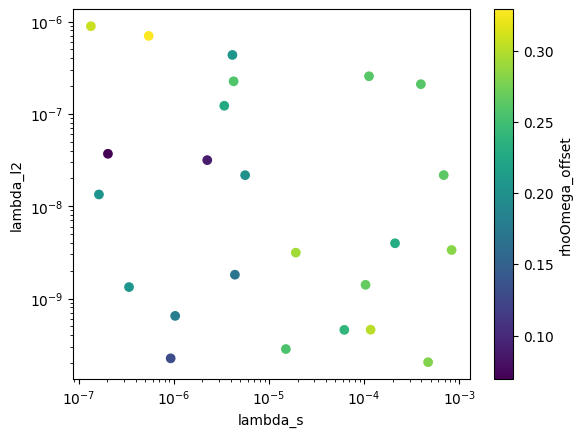

: 

In [ ]:
data=[]

for result in results:
   data.append([result.config["lambda_s"],result.config["lambda_l2"],result.metrics["_metric"]])

data=np.array(data)
#plot data
fig, ax = plt.subplots()
scat=ax.scatter(data[:,0],data[:,1],c=data[:,2],cmap='viridis')

#colorbar
cbar = plt.colorbar(scat,label='rhoOmega_offset')

plt.xscale('log')
plt.yscale('log')

plt.xlabel('lambda_s')
plt.ylabel('lambda_l2')



In [14]:
from ray import train, tune


def objective(config):  # ①
    score = config["a"] ** 2 + config["b"]
    return {"score": score}


search_space = {  # ②
    "a": tune.grid_search([0.001, 0.01, 0.1, 1.0]),
    "b": tune.choice([1, 2, 3]),
}

tuner = tune.Tuner(objective, param_space=search_space)  # ③

results = tuner.fit()
# print(results.get_best_result(metric="score", mode="min").config)

2024-12-05 14:20:14,610	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/ganymed/ray_results/objective_2024-12-05_14-20-12' in 0.0090s.
2024-12-05 14:20:14,619	INFO tune.py:1041 -- Total run time: 2.37 seconds (2.34 seconds for the tuning loop).


In [18]:
results

ResultGrid<[
  Result(
    metrics={'score': 1.000001},
    path='/home/ganymed/ray_results/objective_2024-12-05_14-05-06/objective_8c4e3_00000_0_a=0.0010,b=1_2024-12-05_14-05-06',
    filesystem='local',
    checkpoint=None
  ),
  Result(
    metrics={'score': 2.0001},
    path='/home/ganymed/ray_results/objective_2024-12-05_14-05-06/objective_8c4e3_00001_1_a=0.0100,b=2_2024-12-05_14-05-06',
    filesystem='local',
    checkpoint=None
  ),
  Result(
    metrics={'score': 3.01},
    path='/home/ganymed/ray_results/objective_2024-12-05_14-05-06/objective_8c4e3_00002_2_a=0.1000,b=3_2024-12-05_14-05-06',
    filesystem='local',
    checkpoint=None
  ),
  Result(
    metrics={'score': 3.0},
    path='/home/ganymed/ray_results/objective_2024-12-05_14-05-06/objective_8c4e3_00003_3_a=1.0000,b=2_2024-12-05_14-05-06',
    filesystem='local',
    checkpoint=None
  )
]>

In [7]:
# np.save('data/rho_Multifit_30_corrs_NN',rho)
# np.save('data/total_loss_history_Multifit_30_corrs_NN',total_loss_history)
# np.save('data/loss_history_Multifit_30_corrs_NN',loss_history)

np.save('data/rho_Multifit_30_corrs_rhoFit_NN',rho)
np.save('data/total_loss_history_Multifit_30_corrs_rhoFit_NN',total_loss_history)
np.save('data/loss_history_Multifit_30_corrs_rhoFit_NN',loss_history)

In [23]:
def bootstrapMean(samples):
    mean=np.mean(samples,axis=0)
    mean=np.squeeze(mean)
    return mean

def bootstrapVariance(samples):
    mean=bootstrapMean(samples)
    variance=np.mean((samples-mean)**2,axis=0)
    return variance

/tmp/ipykernel_14375/2786768227.py:2: RuntimeWarning: invalid value encountered in divide
  plt.plot(omega,spec2BW/omega, label=r'True')


Text(0, 0.5, '$\\rho/\\omega$')

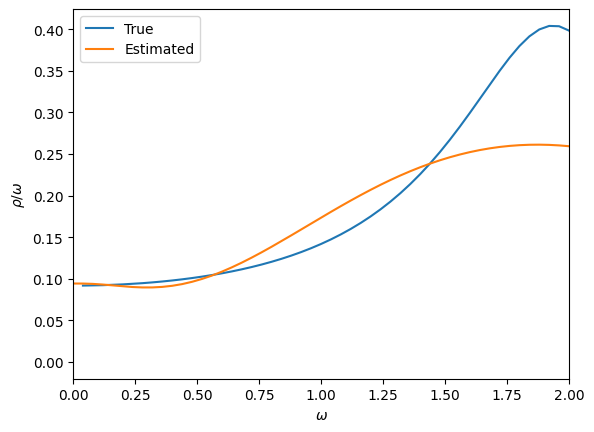

In [34]:
# singlefit result with 1 correlators
plt.plot(omega,spec2BW/omega, label=r'True')
plt.plot(omega,np.squeeze(rho), label=r'Estimated',color='C1')
plt.legend()
plt.xlim(0,2)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')


/tmp/ipykernel_14375/1572968319.py:2: RuntimeWarning: invalid value encountered in divide
  plt.plot(omega,spec2BW/omega, label=r'True')


Text(0, 0.5, '$\\rho/\\omega$')

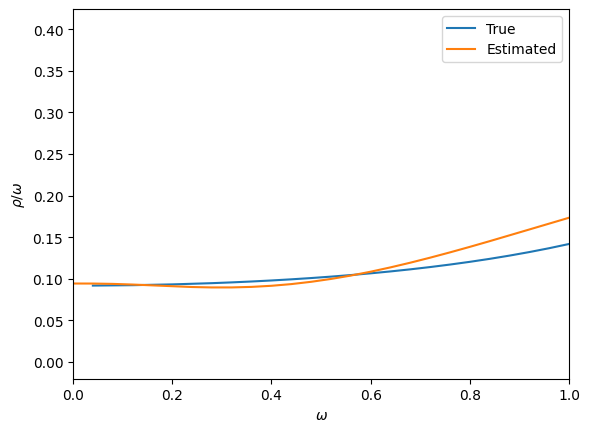

In [37]:
# singlefit result with 1 correlators
plt.plot(omega,spec2BW/omega, label=r'True')
plt.plot(omega,np.squeeze(rho), label=r'Estimated',color='C1')
plt.legend()
plt.xlim(0,1)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')


/tmp/ipykernel_14375/3309905304.py:2: RuntimeWarning: invalid value encountered in divide
  plt.plot(omega,spec2BW/omega, label=r'True')


Text(0, 0.5, '$\\rho/\\omega$')

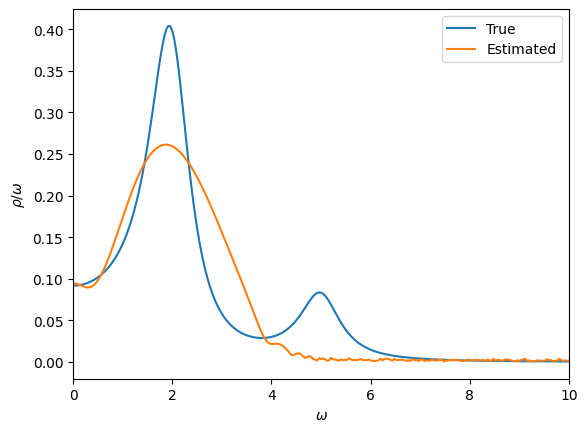

In [40]:
# singlefit result with 1 correlators
plt.plot(omega,spec2BW/omega, label=r'True')
plt.plot(omega,np.squeeze(rho), label=r'Estimated',color='C1')
plt.legend()
plt.xlim(0,10)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')


Text(0.5, 0, 'Epochs')

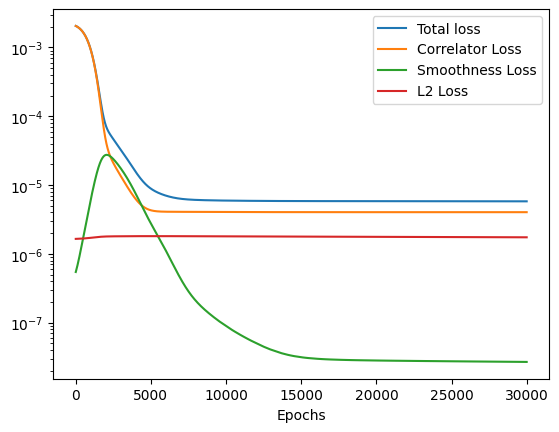

In [35]:
trainingepochs=range(new_epochs)

plt.figure()
plt.plot(trainingepochs,total_loss_history,label=r'Total loss')
plt.plot(trainingepochs,np.squeeze(loss_history).T[0],label=r'Correlator Loss')
plt.plot(trainingepochs,np.squeeze(loss_history).T[1]*lambda_s,label=r'Smoothness Loss')
plt.plot(trainingepochs,np.squeeze(loss_history).T[2]*0.5*lambda_l2,label=r'L2 Loss')

plt.yscale('log')
plt.legend()
plt.xlabel('Epochs')

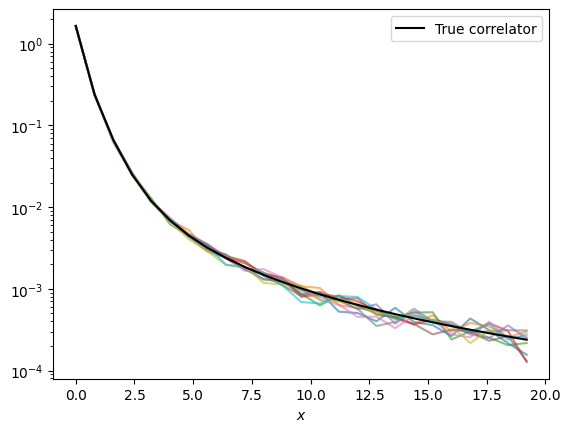

In [13]:

# plt.plot(x,noisy_Dxi_ensemble.T, label=r'Noisy correlator')
for i in range(len(noisy_Dxi_ensemble)):
    plt.plot(x, noisy_Dxi_ensemble[i], alpha=0.6)
plt.plot(x,Dxi_ensemble[0], label=r'True correlator',color='black')
plt.yscale('log')
plt.xlabel(r'$x$')
plt.legend()
plt.show()

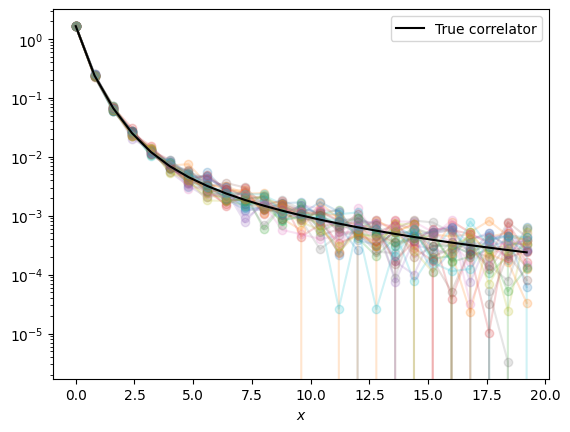

In [9]:

# plt.plot(x,noisy_Dxi_ensemble.T, label=r'Noisy correlator')
for i in range(len(noisy_Dxi_ensemble)):
    plt.plot(x, noisy_Dxi_ensemble[i], alpha=0.2,ls='-',marker='o')
plt.plot(x,Dxi_ensemble[0], label=r'True correlator',color='black')
plt.yscale('log')
plt.xlabel(r'$x$')
plt.legend()
plt.show()

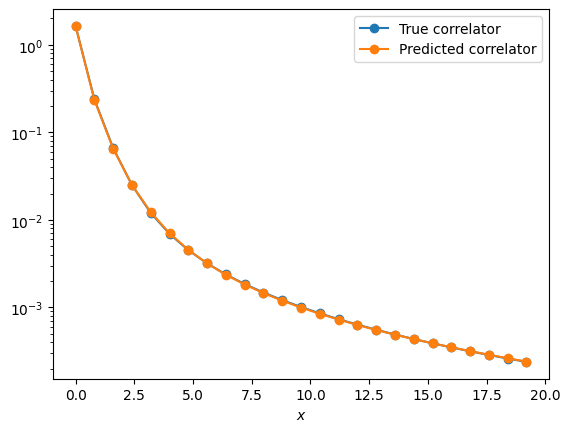

In [38]:
plt.plot(x,Dxi, label=r'True correlator',marker='o')
# plt.plot(x,noisy_Dxi_ensemble.T, label=r'Noisy correlator')
import correlator

klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)
Dxi_prediction=correlator.Di(klW_ker_Pos,rho,del_omega)

plt.plot(x,Dxi_prediction, label=r'Predicted correlator',marker='o')
plt.yscale('log')
plt.xlabel(r'$x$')
# plt.xlim(8,None)
# plt.ylim(None,2e-3)
plt.legend()
plt.show()

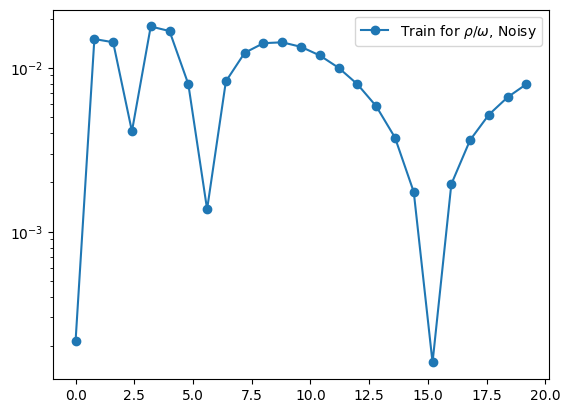

In [39]:
compareCorrelator=noisy_Dxi
plt.plot(x,np.abs(Dxi_prediction-compareCorrelator)/compareCorrelator, label=r'Train for $\rho/\omega$, Noisy',marker='o')
# plt.plot(x,np.abs(Final_DxiWNoisy_stderror-compareCorrelator)/compareCorrelator, label=r'Train for $\rho/\omega$, Noisy with std error',marker='o')
plt.yscale('log')
plt.legend()
plt.show()

In [19]:
compareCorrelator=Dxi
plt.plot(x,np.abs(Final_DxiWNoisy-compareCorrelator)/compareCorrelator, label=r'Train for $\rho/\omega$, Noisy',marker='o')
plt.plot(x,np.abs(Final_DxiWNoisy_stderror-compareCorrelator)/compareCorrelator, label=r'Train for $\rho/\omega$, Noisy with std error',marker='o')
plt.yscale('log')
plt.legend()
plt.show()

NameError: name 'Dxi' is not defined

# Behaviour of the kernal with $\omega$ and $p$.  

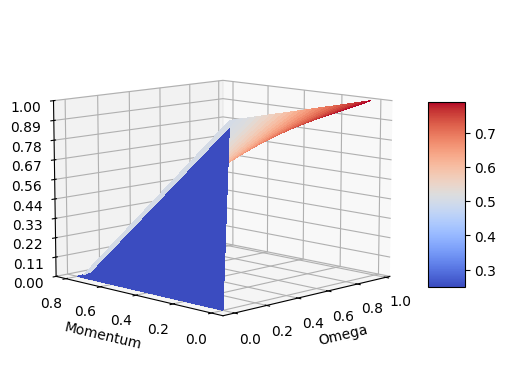

In [ ]:
from matplotlib import cm
from matplotlib.ticker import LinearLocator

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Make data X = Omega, Y = momentum.
X = np.arange(0, 1, 0.04)
Y = np.arange(epsilon, 1+epsilon, del_pi)
X, Y = np.meshgrid(X, Y)
R = X**2 + Y**2
Z = X**2/R

plt.xlabel('Omega')
plt.ylabel('Momentum')
# Plot the surface.
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

# Customize the z axis.
ax.set_zlim(0, 1)
ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.02f}')

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)

ax.view_init(elev=10, azim=225) 

plt.show()

# Bootstrapping
Here we want to generate many spectral functions corresponding to different noisy instances of the correlator and then bootstrap over these samples, which are then to be compared to the other approach.

In [ ]:
# new custom class iheriting from base class - here structure is added to simple layers above
class CustomTrainingModel(SpectralNN):
    def __init__(self, num_output_nodes, width=64, depth=3, lambda_s=None, lambda_l2=None, kl_ker=None, del_omega=None, gauss_width=None):
        super(CustomTrainingModel, self).__init__(num_output_nodes, width, depth)
        self.lambda_s = lambda_s
        self.lambda_l2 = lambda_l2
        self.kl_ker = kl_ker
        self.del_omega = del_omega
        self.gauss_width = gauss_width
    
    def compute_predictions(self, x):
        return self(x, training=True)
    
    def train_step(self, data):
        x, y = data  # Only unpack x and y (because Keras only passes two values)
        
        with tf.GradientTape() as tape:
            # Forward pass: Compute predictions - Gradient tape keeps track of gradients to allow explicit automatic differentiation
            rhoi_predN = self.compute_predictions(x)
            
            # Reconstruct correlator using external Di function (using stored kl_ker and del_omega)
            y_predN = Di(self.kl_ker, rhoi_predN, self.del_omega)
            
            # Compute custom loss (including smoothness and L2 regularization)
            loss = custom_loss(y, y_predN, gauss_width)
            total_loss_value = total_loss(loss, rhoi_predN, self, self.lambda_s, self.lambda_l2)  # Include smoothness and L2 terms
        
        # Compute gradients and update weights
        gradients = tape.gradient(total_loss_value, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))
        
        return {"loss": total_loss_value}

# Create input data and target
constant_input = tf.constant([[1.0]], dtype=tf.float32)  # Constant input node which goes to 500 omegas as the NN structure in paper
target_output = tf.convert_to_tensor(noisy_dpi_tensor)

#the smothness and rigde regularisation coeffcicients - feel free to modify
lambda_s = 1.0e-3
lambda_l2 = 1.0e-6
gauss_width = np.ones(25) #for mean square error
#gauss_width = custom_std #for chi square error

# Initialize the model
# Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased

In [ ]:
#The actual training loops
output_rho_tensor = []
output_Dpi_tensor = []

for ii in range(target_output.shape[0]):
    print('\n',ii,'\n')
    model = CustomTrainingModel(num_output_nodes=500, width=64, depth=3, lambda_s=lambda_s, lambda_l2=lambda_l2, kl_ker=klW_ker, del_omega=del_omega, gauss_width=gauss_width)
    
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
    
    epochs=2000
# Custom Training Loop for the smootheness part (called "Warm up loop" in the paper)
    for epoch in range(epochs):

        with tf.GradientTape() as tape:
        # Forward pass: Compute predictions
            rhoi_pred = model(constant_input) # Shape 500
        
        # Reconstruct correlator using Di function
            y_pred = Di(kl_ker, rhoi_pred, del_omega)  # Shape 25
        
            main_loss += custom_loss(target_output[ii], y_pred, gauss_width)

            total_loss_value = total_loss(main_loss, rhoi_pred, model, lambda_s, lambda_l2) 
    
    # Compute gradients and update weights
        gradients = tape.gradient(total_loss_value, model.trainable_weights)
        optimizer.apply_gradients(zip(gradients, model.trainable_weights))
    
    #print(f"Loss: {total_loss_value.numpy()}")

    print("Warm up complete.")

    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5) #notice the lower learning rate
    new_epochs = 10000
    loss_history = []
    for epoch in range(new_epochs):
    #print(f'Resuming Epoch {epoch + 1}/{new_epochs}')
    
        with tf.GradientTape() as tape:
        # Forward pass: Compute predictions
            rhoi_pred = model(constant_input) # Shape 500
        
        # Reconstruct correlator using Di function
            y_pred = Di(kl_ker, rhoi_pred, del_omega)  # Shape 25
        
            main_loss += custom_loss(target_output[ii], y_pred, gauss_width)
  
            total_loss_value = total_loss(main_loss, rhoi_pred, model, lambda_s=0, lambda_l2=1.0e-8)
    
    # Compute gradients and update weights
        gradients = tape.gradient(total_loss_value, model.trainable_weights)
        optimizer.apply_gradients(zip(gradients, model.trainable_weights))

    #print(f"Loss: {total_loss_value.numpy()}")
        loss_history.append(total_loss_value.numpy())

    Final_rho_FT = rhoi_pred.numpy().reshape(-1)
    Final_Dpi_FT = y_pred.numpy().reshape(-1)
    output_rho_tensor.append(Final_rho_FT)
    output_Dpi_tensor.append(Final_Dpi_FT)
    print("Training complete for additional epochs.")





 0 

Warm up complete.
Training complete for additional epochs.

 1 

Warm up complete.
Training complete for additional epochs.

 2 

Warm up complete.
Training complete for additional epochs.

 3 

Warm up complete.
Training complete for additional epochs.

 4 

Warm up complete.
Training complete for additional epochs.

 5 

Warm up complete.
Training complete for additional epochs.

 6 

Warm up complete.
Training complete for additional epochs.

 7 

Warm up complete.
Training complete for additional epochs.

 8 

Warm up complete.
Training complete for additional epochs.

 9 

Warm up complete.
Training complete for additional epochs.

 10 

Warm up complete.
Training complete for additional epochs.

 11 

Warm up complete.
Training complete for additional epochs.

 12 

Warm up complete.
Training complete for additional epochs.

 13 

Warm up complete.
Training complete for additional epochs.

 14 

Warm up complete.
Training complete for additional epochs.

 15 

Warm up compl

In [ ]:
output_rho = tf.convert_to_tensor(output_rho_tensor,dtype=tf.float32)
output_Dpi = tf.convert_to_tensor(output_Dpi_tensor,dtype=tf.float32)

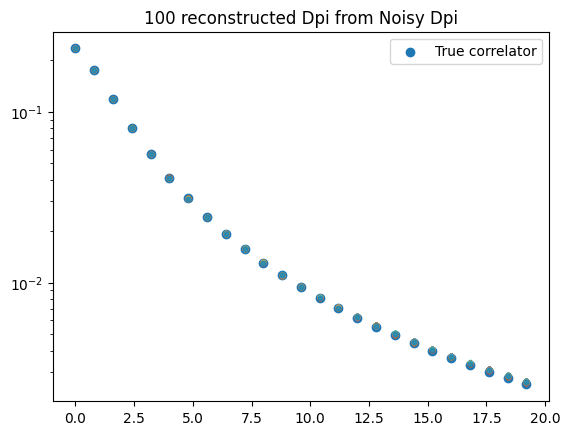

In [ ]:
plt.scatter(p,Dpi, label=r'True correlator')
for i in range(100):
    plt.scatter(p, output_Dpi[i], s=10, alpha=0.6)

plt.title(r'100 reconstructed Dpi from Noisy Dpi')
plt.yscale('log')

plt.legend()
#plt.savefig('NN_ReconstructedCorrelator_1BW_100Machines100outputsL21em6.png')
plt.show()

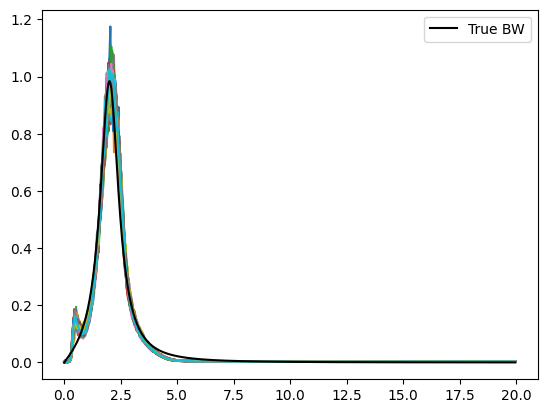

In [ ]:
for i in range(100):
    plt.plot(omega, output_rho[i])
plt.plot(omega,spec1BW,color='black', label=r'True BW')
#plt.plot(omega,Final_rho,'-.r', label=r'Multi Fit Single $\rho$')
plt.legend()
#plt.savefig('Comp_NN_ReconstructedRho_1BW_100Machines100outputsL21em6.png')
plt.show()

In [ ]:
#Bootstrap analysis
# Number of bootstrap samples to generate
output_rho_np = output_rho.numpy()
n_bootstrap_samples = 1000
bootstrap_means = []
# Generate bootstrap samples
for _ in range(n_bootstrap_samples):
    
    bootstrap_sample = output_rho_np[np.random.choice(output_rho_np.shape[0], size=output_rho_np.shape[0], replace=True)]
    bootstrap_mean = np.mean(bootstrap_sample, axis=0, keepdims=True)
    bootstrap_means.append(bootstrap_mean)

# Convert to NumPy array for analysis
bootstrap_means = np.array(bootstrap_means)

# Estimate the error (standard deviation of bootstrap means)
bootstrap_error = np.std(bootstrap_means,axis=0)


In [ ]:
np.shape(bootstrap_means), np.shape(bootstrap_error), np.shape(MeanMean)
#test = tf.convert_to_tensor(bootstrap_samples)
#tf.shape(test)
#bootstrap_means = np.squeeze(bootstrap_means, axis=1)
#bootstrap_error = bootstrap_error.reshape(500)
#MeanMean = np.mean(bootstrap_means,axis=0)

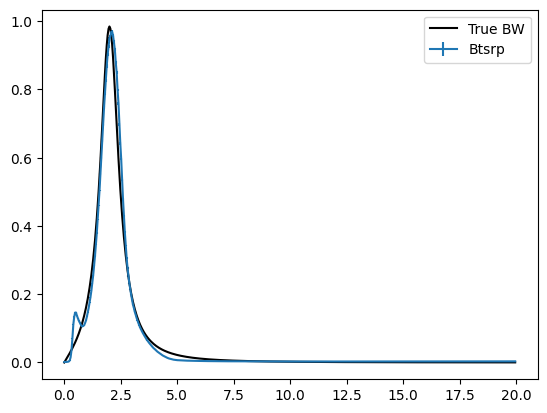

In [ ]:
plt.errorbar(omega, MeanMean, yerr=bootstrap_error, label=r'Btsrp')
plt.plot(omega,spec1BW,color='black', label=r'True BW')
#plt.plot(omega,Final_rho,color='red', label=r'Multi Fit Single $\rho$')
plt.legend()
#plt.savefig('NN_ReconstructedCorrelator_10Kepochs1BW1e-3.png')
plt.show()